# ASSIGNMENT 11 - DECISION TREE

In [69]:
# Data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Set plotting style
sns.set_theme(style="whitegrid")


In [70]:

# Load the heart disease dataset
df = pd.read_csv("heart_disease.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   age  Gender  cp  trestbps  chol  fbs  restecg  thalch  exang  oldpeak  \
0   67       0   4       101   245    0        0     181      0      2.4   
1   57       0   2       156   281    0        0     146      0      5.4   
2   43       1   2       104   300    1        2     178      0      3.8   
3   71       1   2       174   292    0        1     139      1      4.8   
4   36       0   4       101   320    0        1     112      1      3.0   

   slope  thal  num  
0      3     3    4  
1      2     2    0  
2      3     3    3  
3      1     2    4  
4      2     2    0  


In [71]:

# Dataset shape
print("\nDataset Shape:", df.shape)

# Dataset information (data types & null values)
print("\nDataset Info:")
df.info()

# Check for missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())



Dataset Shape: (40, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       40 non-null     int64  
 1   Gender    40 non-null     int64  
 2   cp        40 non-null     int64  
 3   trestbps  40 non-null     int64  
 4   chol      40 non-null     int64  
 5   fbs       40 non-null     int64  
 6   restecg   40 non-null     int64  
 7   thalch    40 non-null     int64  
 8   exang     40 non-null     int64  
 9   oldpeak   40 non-null     float64
 10  slope     40 non-null     int64  
 11  thal      40 non-null     int64  
 12  num       40 non-null     int64  
dtypes: float64(1), int64(12)
memory usage: 4.2 KB

Missing Values in Each Column:
age         0
Gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: 

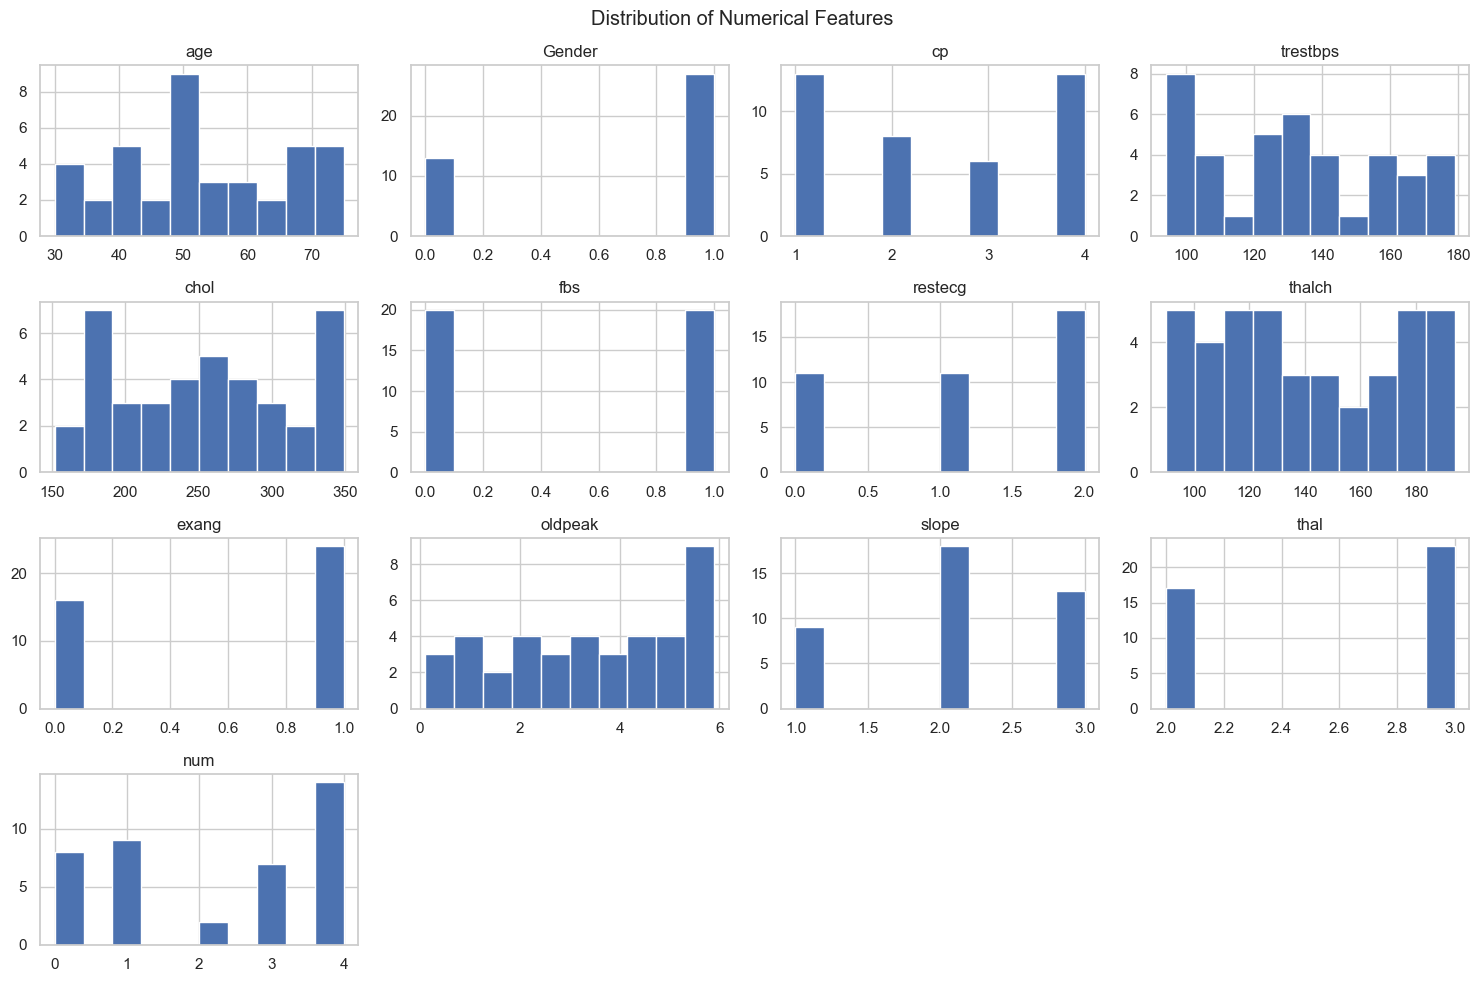

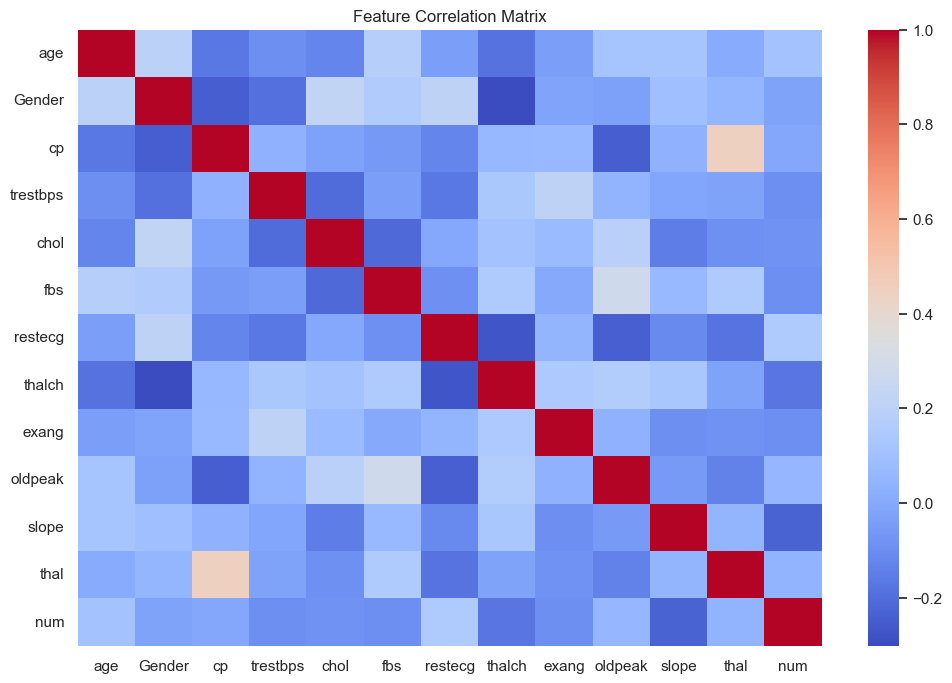

In [72]:

# Histograms for numerical features
df.hist(figsize=(15, 10))
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


In [73]:

# STEP 5: FEATURE ENGINEERING

"""
Original target variable 'num' has 5 classes (0–4).
This causes poor performance due to:
- Small dataset
- Severe class imbalance

Medical interpretation:
0 → No heart disease
1–4 → Heart disease present

Hence, convert it into binary classification.
"""

# Create binary target variable
df["target"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

# Drop the original multiclass target
df.drop("num", axis=1, inplace=True)

# Verify target distribution
print("\nBinary Target Distribution:")
print(df["target"].value_counts())



Binary Target Distribution:
target
1    32
0     8
Name: count, dtype: int64


In [74]:

# STEP 6: SPLIT FEATURES AND TARGET


X = df.drop("target", axis=1)  # Input features
y = df["target"]               # Target variable


In [75]:

# STEP 7: TRAIN–TEST SPLIT


"""
Stratify ensures class balance is maintained
in both training and testing sets.
"""

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 32
Testing Samples: 8


In [76]:

# STEP 8: BASE DECISION TREE MODEL

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Decision Tree with class balancing
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred = dt_model.predict(X_test)

# Evaluate base model
print("Base Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("\nBase Decision Tree Classification Report:")
print(classification_report(y_test, y_pred))


Base Decision Tree Accuracy: 0.5

Base Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.67      0.67      0.67         6

    accuracy                           0.50         8
   macro avg       0.33      0.33      0.33         8
weighted avg       0.50      0.50      0.50         8



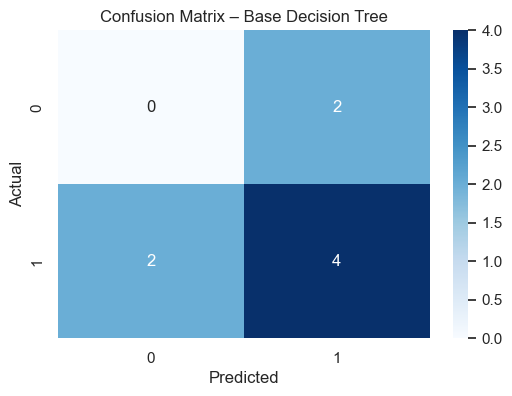

In [77]:

# STEP 9: CONFUSION MATRIX


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Base Decision Tree")
plt.show()


In [78]:

# STEP 10: DECISION TREE HYPERPARAMETER TUNING


from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for pruning
param_grid = {
    "max_depth": [3, 4, 5],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

# GridSearch with class balancing
grid_search = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid,
    cv=5,
    scoring="accuracy"
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Extract best model
best_dt_model = grid_search.best_estimator_

print("Best Decision Tree Parameters:", grid_search.best_params_)


Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [79]:

# STEP 11: TUNED DECISION TREE EVALUATION


# Predict using tuned model
y_pred_best = best_dt_model.predict(X_test)

# Accuracy & report
dt_test_accuracy = accuracy_score(y_test, y_pred_best)

print("Tuned Decision Tree Test Accuracy:", dt_test_accuracy)
print("\nTuned Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_best))


Tuned Decision Tree Test Accuracy: 0.625

Tuned Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.80      0.67      0.73         6

    accuracy                           0.62         8
   macro avg       0.57      0.58      0.56         8
weighted avg       0.68      0.62      0.65         8



In [80]:

# STEP 12: ROC–AUC SCORE


roc_auc = roc_auc_score(
    y_test,
    best_dt_model.predict_proba(X_test)[:, 1]
)

print("ROC–AUC Score:", roc_auc)


ROC–AUC Score: 0.5


In [81]:

# STEP 13: CROSS-VALIDATION ACCURACY


from sklearn.model_selection import cross_val_score

# Cross-validation on full dataset
cv_scores = cross_val_score(
    best_dt_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

dt_cv_accuracy = cv_scores.mean()

print("Decision Tree CV Scores:", cv_scores)
print("Mean Decision Tree CV Accuracy:", dt_cv_accuracy)


Decision Tree CV Scores: [0.5  0.75 0.5  0.75 0.5 ]
Mean Decision Tree CV Accuracy: 0.6


In [82]:

# STEP 14: RANDOM FOREST CLASSIFIER


from sklearn.ensemble import RandomForestClassifier

# Random Forest with class balancing
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Cross-validation for Random Forest
rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

rf_cv_accuracy = rf_scores.mean()

print("Random Forest CV Scores:", rf_scores)
print("Mean Random Forest CV Accuracy:", rf_cv_accuracy)


Random Forest CV Scores: [0.875 0.875 0.75  0.75  0.75 ]
Mean Random Forest CV Accuracy: 0.8


In [83]:

# STEP 13: OVERALL PERFORMANCE SUMMARY


import pandas as pd

summary = pd.DataFrame({
    "Model": [
        "Decision Tree (Test)",
        "Decision Tree (5-Fold CV)",
        "Random Forest (5-Fold CV)"
    ],
    "Accuracy": [
        dt_test_accuracy,
        dt_cv_accuracy,
        rf_cv_accuracy
    ]
})

print("\nOVERALL MODEL PERFORMANCE SUMMARY")
print(summary)



OVERALL MODEL PERFORMANCE SUMMARY
                       Model  Accuracy
0       Decision Tree (Test)     0.625
1  Decision Tree (5-Fold CV)     0.600
2  Random Forest (5-Fold CV)     0.800


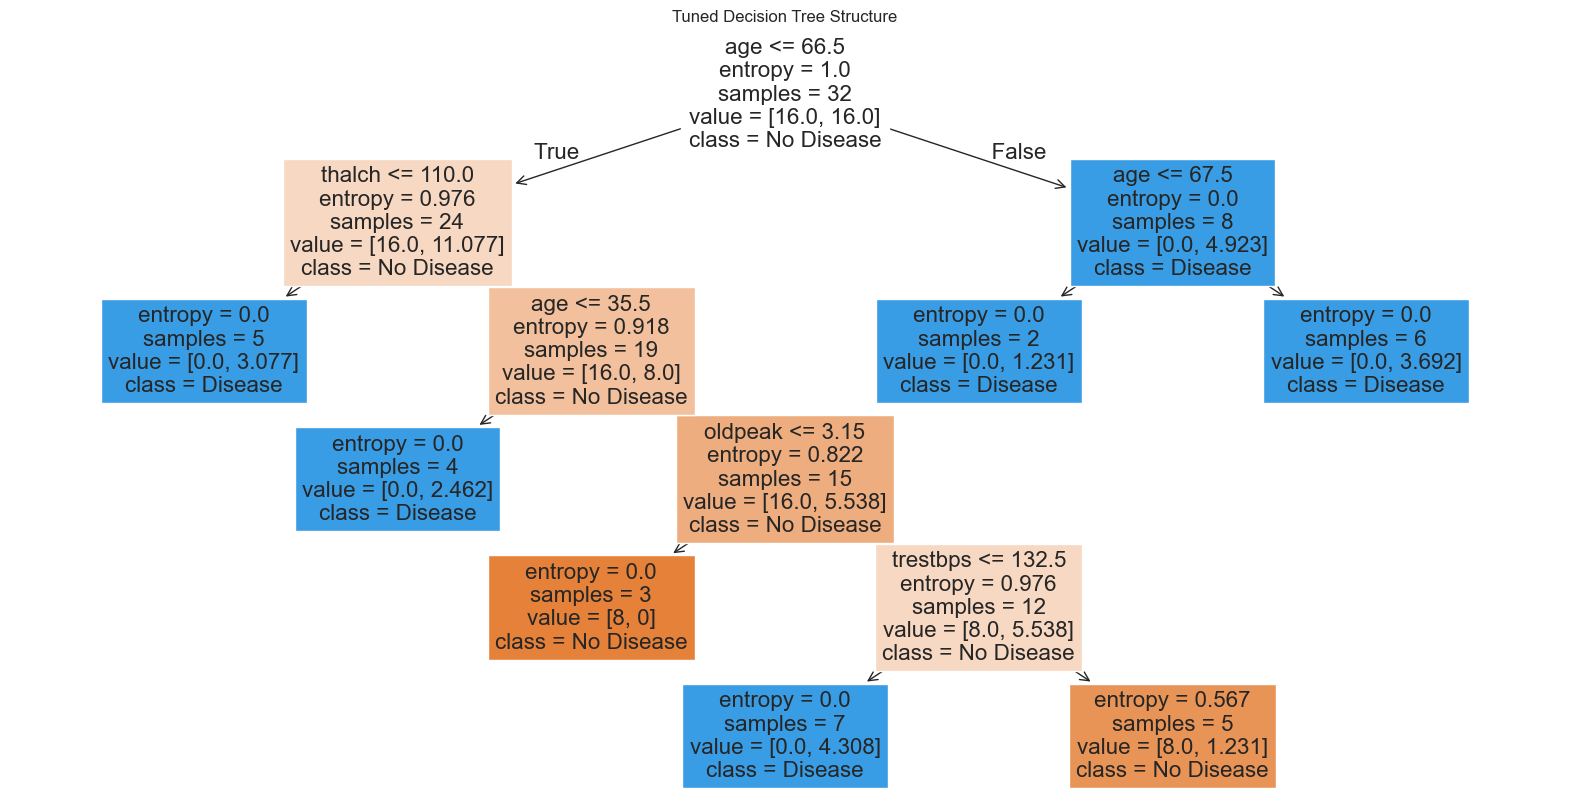

In [84]:

# STEP 13: DECISION TREE VISUALIZATION

plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True
)
plt.title("Tuned Decision Tree Structure")
plt.show()


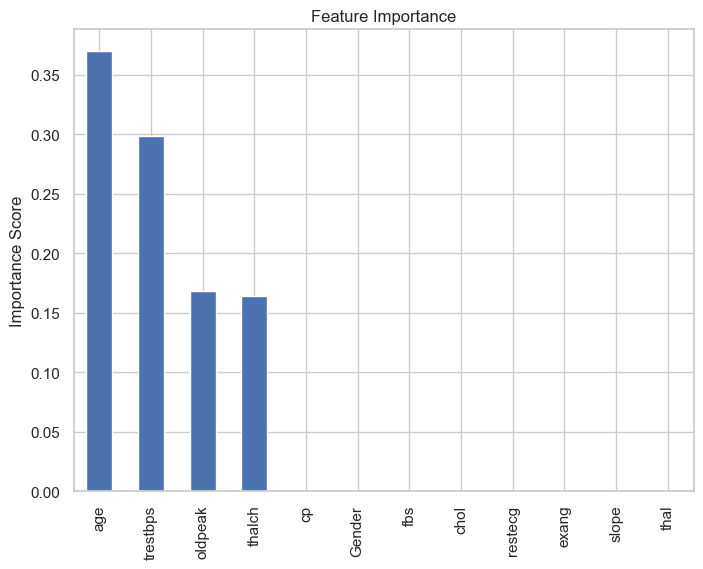

In [85]:

# STEP 14: FEATURE IMPORTANCE

importance = pd.Series(
    best_dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()


# INTERVIEW QUESTIONS

In [86]:
# Q 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

# Common hyperparameters of a Decision Tree model include:

# max_depth: Controls the maximum depth of the tree. A deeper tree can learn complex patterns but may cause overfitting. A smaller depth helps prevent overfitting.

# min_samples_split: Specifies the minimum number of samples required to split an internal node. Higher values make the tree more general and reduce overfitting.

# min_samples_leaf: Defines the minimum number of samples required in a leaf node. It helps smooth the model and improves generalization.

# criterion: Determines the metric used to measure the quality of a split. Common options are gini and entropy. Both aim to create purer child nodes.

# max_features: Specifies the number of features to consider when looking for the best split. Limiting features can reduce overfitting.

In [87]:
# Q 2. What is the difference between Label Encoding and One-Hot Encoding?

# Label Encoding and One-Hot Encoding are techniques used to convert categorical data into numerical form.

# Label Encoding:

    # Assigns a unique numeric value to each category.

    # Example: Male = 1, Female = 0

    # Best suited for ordinal data where order matters.

    # May introduce incorrect order for nominal data.

# One-Hot Encoding:

    # Creates separate binary columns for each category.

    # Example: Male → [1, 0], Female → [0, 1]

    # Best suited for nominal data where no order exists.

    # Avoids misleading relationships between categories.